In [68]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

In [69]:
df = pd.read_csv('gemini.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Пол               60 non-null     int64  
 1   Кортизол          60 non-null     float64
 2   Глюкоза           60 non-null     float64
 3   Молочная к-та     60 non-null     float64
 4   Инсулин           60 non-null     float64
 5   МДА (Эритроциты)  60 non-null     float64
 6   ФЛ(эр)            60 non-null     float64
 7   СХ(эр)            60 non-null     float64
 8   НЭЖК(эр)          60 non-null     float64
 9   ТГ(эр)            60 non-null     float64
 10  ЭХС(эр)           60 non-null     float64
 11  МДА (Плазма)      60 non-null     float64
 12  ФЛ(пл)            60 non-null     float64
 13  СХ(пл)            60 non-null     float64
 14  НЭЖК(пл)          60 non-null     float64
 15  ТГ(пл)            60 non-null     float64
 16  ЭХС(пл)           60 non-null     float64
 17  З/П       

In [70]:
y = df['З/П']
X = df.drop(['З/П'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [78]:
model = CatBoostClassifier(
    iterations=1500,           # для маленьких данных лучше меньше итераций + раннее стоппинг
    learning_rate=0.001,
    depth=4,
    auto_class_weights='Balanced', # Решает проблему дисбаланса 0 и 1
    eval_metric='F1',          # Оптимизируем под дисбаланс, а не под точность
    verbose=10,               # Выводить лог каждые 100 шагов
    random_seed=42
)

# 3. Обучение с защитой от переобучения
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50   # Остановится, если F1 перестанет расти
)

# 4. Получение вероятностей
y_proba = model.predict_proba(X_test)[:, 1]

# 5. Предсказание классов
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

0:	learn: 0.8571429	test: 0.5714286	best: 0.5714286 (0)	total: 1.21ms	remaining: 1.81s
10:	learn: 0.9473684	test: 0.8235294	best: 0.8888889 (6)	total: 11.9ms	remaining: 1.61s
20:	learn: 0.9473684	test: 0.8888889	best: 0.8888889 (6)	total: 21.2ms	remaining: 1.5s
30:	learn: 0.9743590	test: 0.8888889	best: 0.8888889 (6)	total: 29.6ms	remaining: 1.4s
40:	learn: 0.9473684	test: 0.8888889	best: 0.8888889 (6)	total: 38.8ms	remaining: 1.38s
50:	learn: 0.9473684	test: 0.8888889	best: 0.8888889 (6)	total: 46.7ms	remaining: 1.33s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8888888889
bestIteration = 6

Shrink model to first 7 iterations.
              precision    recall  f1-score   support

         0.0       0.80      1.00      0.89         8
         1.0       1.00      0.80      0.89        10

    accuracy                           0.89        18
   macro avg       0.90      0.90      0.89        18
weighted avg       0.91      0.89      0.89        18



In [79]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 88.89%


Accuracy:0.889
Precision:1.000
Recall:  0.800
F1-score: 0.889

Confusion Matrix:
 [[8 0]
 [2 8]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      1.00      0.89         8
         1.0       1.00      0.80      0.89        10

    accuracy                           0.89        18
   macro avg       0.90      0.90      0.89        18
weighted avg       0.91      0.89      0.89        18

0:	learn: 0.9333333	total: 1.11ms	remaining: 1.67s
10:	learn: 1.0000000	total: 6.2ms	remaining: 839ms
20:	learn: 1.0000000	total: 11.6ms	remaining: 815ms
30:	learn: 1.0000000	total: 17.3ms	remaining: 820ms
40:	learn: 1.0000000	total: 22.9ms	remaining: 815ms
50:	learn: 1.0000000	total: 28.6ms	remaining: 812ms
60:	learn: 1.0000000	total: 35.3ms	remaining: 833ms
70:	learn: 1.0000000	total: 41.4ms	remaining: 833ms
80:	learn: 1.0000000	total: 46.2ms	remaining: 810ms
90:	learn: 1.0000000	total: 51.7ms	remaining: 800ms
100:	learn: 1.0000000	total: 57.4

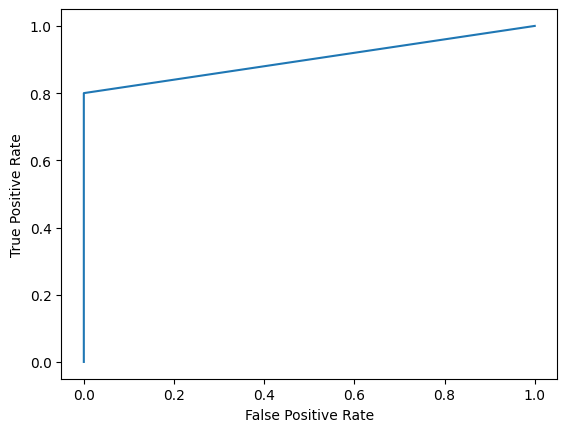

In [80]:
def metrix(prediction,clf, X_test):
    from sklearn.model_selection import cross_val_score
    accuracy_score(prediction, y_test)
    print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
    print(f"Precision:{precision_score(y_test, prediction):.3f}")
    print(f"Recall:  {recall_score(y_test, prediction):.3f}")
    print(f"F1-score: {f1_score(y_test, prediction):.3f}")
    # print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
    print("\nClassification Report:\n", classification_report(y_test, prediction))


    scores_f1 = cross_val_score(clf, X_test, y_test, cv=5, scoring='f1')

    print(f"F1-результаты по фолдам: {scores_f1}")
    print(f"Средний F1: {scores_f1.mean():.2f}")
    from sklearn import metrics
    fpr, tpr, _ = metrics.roc_curve(y_test,  prediction)

    # построение ROC кривой
    plt.plot(fpr, tpr)
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    return
metrix(y_pred, model, X_test)

In [81]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:0.889
Precision:1.000
Recall:  0.800
F1-score: 0.889
ROC-AUC:0.963

Confusion Matrix:
 [[8 0]
 [2 8]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      1.00      0.89         8
         1.0       1.00      0.80      0.89        10

    accuracy                           0.89        18
   macro avg       0.90      0.90      0.89        18
weighted avg       0.91      0.89      0.89        18



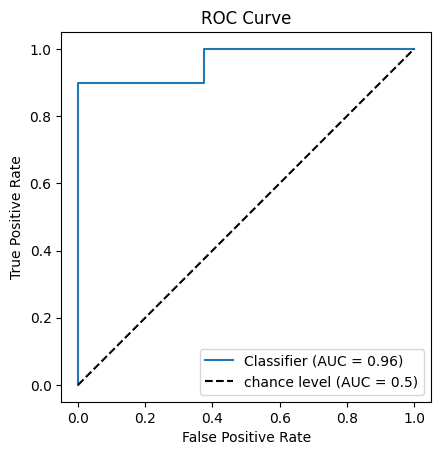

In [82]:
RocCurveDisplay.from_predictions(y_test, y_proba)

plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)") 
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

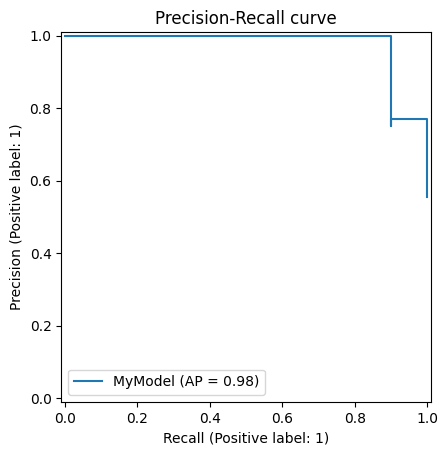

In [83]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_proba, name="MyModel")

_ = display.ax_.set_title("Precision-Recall curve")
plt.show()

<class 'numpy.ndarray'>


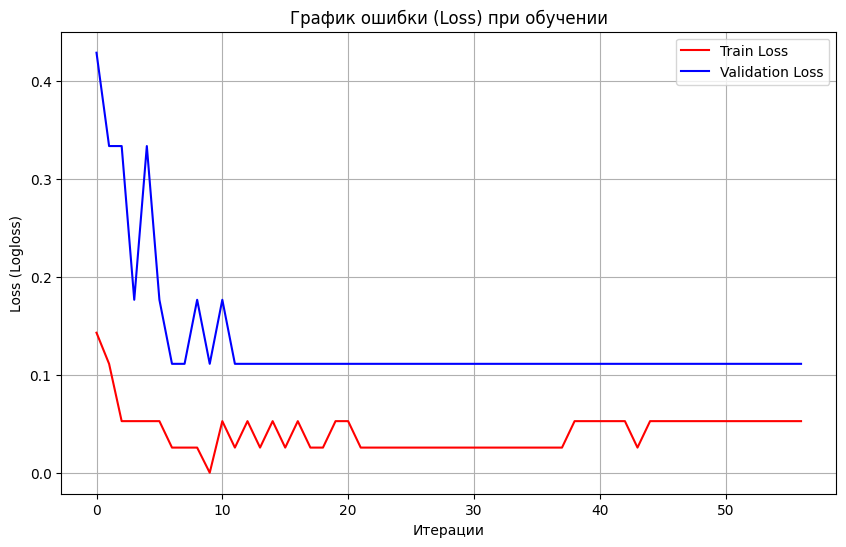

In [89]:
import matplotlib.pyplot as plt

import numpy as np

def plot_learning_loss(model):
    results = model.get_evals_result()
    
    # Извлекаем Logloss (это и есть ошибка/loss в CatBoost по умолчанию)
    train_loss =  np.abs(np.array(results['learn']['F1'])-1)
    test_loss =  np.abs(np.array(results['validation']['F1'])-1)
    print(type(train_loss))
    epochs = range(len(train_loss))

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_loss, 'r', label='Train Loss')
    plt.plot(epochs, test_loss, 'b', label='Validation Loss')
    
    plt.title('График ошибки (Loss) при обучении')
    plt.xlabel('Итерации')
    plt.ylabel('Loss (Logloss)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Вызов функции после model.fit
plot_learning_loss(model)
